# **Часть 1 -  Сборка с Velvet**

SLURM скрипт velvet.slurm находится в папке hw4.

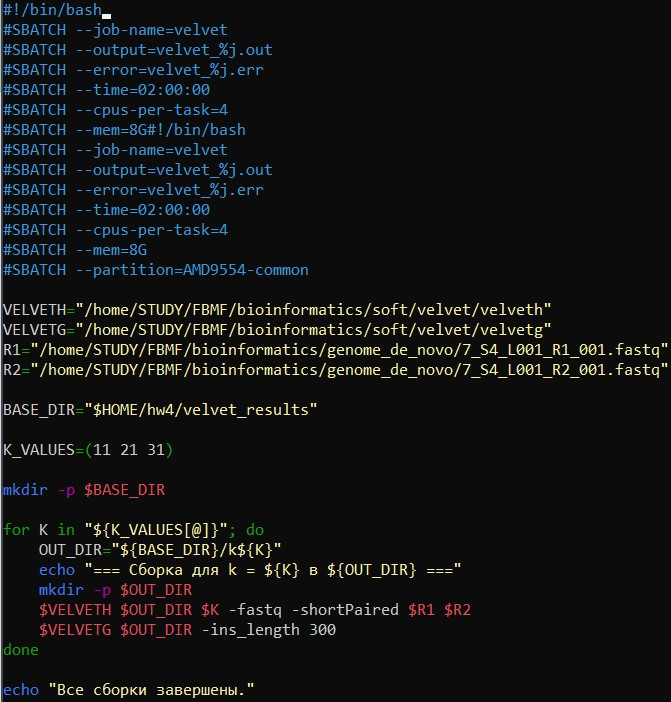

Скриншот с результатом работы скрипта:

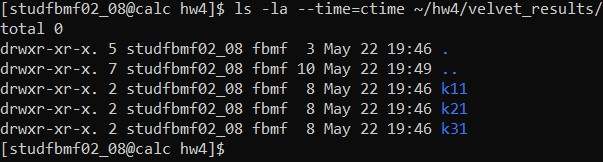

# **Часть 2 — Сравнение сборок**

Результаты сравнения QUAST находятся в /hw4/quast_comparison/report.tsv .

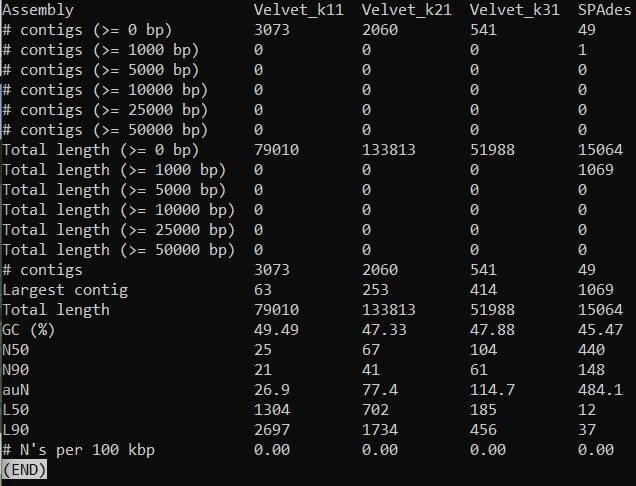

Какие **выводы** можно сделать:

- SPAdes уверенно лидирует по качеству сборки: у него минимальное число контигов (всего 49 против 541 у Velvet_k31, у остальных и того больше) и максимальная длина фрагментов (1069 п.н., против всего 414 у лучшего результата Velvet-а). Чем меньше фрагментов и чем они длиннее при сопоставимой суммарной длине, тем сборка цельнее.


- L50: для получения 50% генома SPAdes достаточно всего 12 самых крупных контигов, у Velvet это число на порядок(-ки) больше.

- N50: половина длины сборки приходится на фрагменты длиной от 440 п.н. и более — это выше, чем у любого варианта Velvet.

**Итого:**

Velvet даёт более раздробленную сборку, особенно при k=11 и k=21. Повышение k-мера до 31 улучшает результат, но даже в этом случае Velvet заметно уступает SPAdes.

# **Часть 3 — Улучшение сборки**

Для улучшения сборки DPAdes выберем режим --isolate, который оптимизирует алгоритм сборки, уменьшая количество ложных связей в графе и лучше обрабатывая повторы. В нашем случае вирус гриппа имеет высокое покрытие, поэтому --isolate даст более непрерывные контиги, чем стандартный --careful.

Для улучшения сборки Velvet применяем предобработку ридов с помощью fastp: отсечение коротких контигов (-min_contig_lgth 200). Берем k = 31, т.к. при нем был наилучший результат.

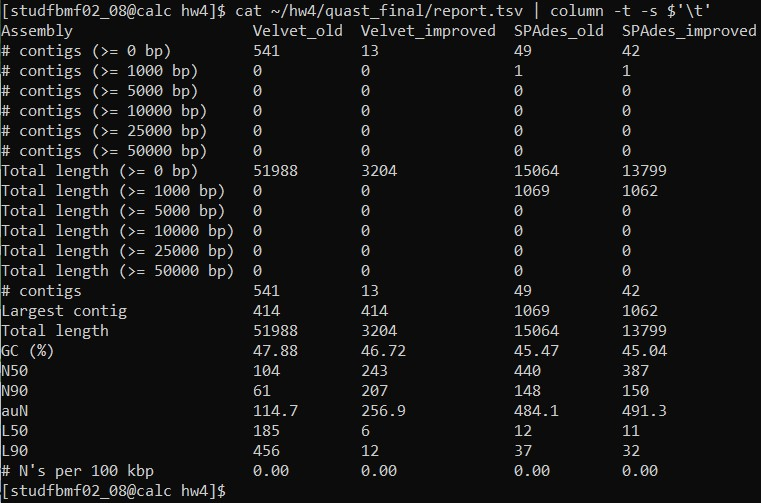

**Выводы:**

- Улучшенная сборка через Velvet стала гораздо более непрерывной: число контигов сократилось с 541 до 13, N50 вырос со 104 до 243, L50 упал с 185 до 6. Однако общая длина очень сильно уменьшилась из-за того, что мы просто удаляли мелкие фрагменты. Итог: сильный рост качества фрагментации ценой потери почти всего объёма сборки.

- Для сборки через SPAdes изменения незначительные: число контигов уменьшилось с 49 до 42, общая длина снизилась на 8%. Показатели L50/L90 немного улучшились, N50 слегка снизился. Итог: небольшая «чистка» сборки без радикальных потерь или улучшений.

# **Финальные выводы**

В результате можем сказать, что SPAdes в данном случае демонстрирует бОльшую устойчивость к качеству исходных данных и даёт более качественные сборки. Для Velvet же критически важны предварительная обработка и фильтрация: без них сборка оказывается чрезмерно фрагментированной, а с ними — теряет в полноте. Кроме того, на результат Velvet сильно влияет выбор k-меров.